# Early Fusion MLP Pipeline

## 1. Imports

Below we import the needed libraries and functions.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from FusionModels.utils import cross_validation_5fold_early_fusion, hyperparameter_tuning

ModuleNotFoundError: No module named 'EarlyFusion'

## 2. Concatenation

The audio and tapping features dataframes are concatenated into a single features dataframe. This, in turn, will be fed to the MLP. 

Note that, each patient has either more tapping trials or more audio trials. To deal with this, for each patient we randomely downsample the number of trials in the dataframe that contains more trials, for that patient, to have exactly the minimum number of trials that originally existed in either CSV. This is needed as our concatenation is actually a column binding.

In [ ]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"

audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in TAPPING_FEATURES.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

counts_audio_balanced["row_id"] = counts_audio_balanced.groupby("healthCode").cumcount()
counts_tapping_balanced["row_id"] = counts_tapping_balanced.groupby("healthCode").cumcount()

# Verify that there are the same amount of trials in both dataframes
print("Balanced trials count match:", len(counts_audio_balanced) == len(counts_tapping_balanced))

# Verify that heatlthCodes are properly aligned
print("Columns aligned:", all(
    counts_audio_balanced["healthCode"].values == counts_tapping_balanced["healthCode"].values
))

features_merged = pd.merge(
    counts_audio_balanced,
    counts_tapping_balanced,
    on=["healthCode", "row_id"],
    suffixes=("_file1", "_file2")
)

features_merged.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv", index=False)


/tmp/ipykernel_137353/1548881163.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_137353/1548881163.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))


## 3. Data Loading

Below, we specify the absolute paths to the needed dataframes (CSVs) for the MLP.

In [2]:
FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv"
LABELS = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 4. Cross-Validation & Hyperparameter Tuning 

Using the given 5-folds, we call a hyperparameter tuning fucntion which itself calls our cross-validation function. In this way, we find the best possible early fusion MLP.

In [ ]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

hyperparam_tuning_res = hyperparameter_tuning(
    features_csv = FUSION_FEATURES,
    labels_csv = LABELS,
    train_folds_csv = TRAIN_FOLDS,
    val_test_folds_csv = VAL_TEST_FOLDS,
    output_dir = output_dir_mlp,
    hidden_dims = [[256, 128, 64, 32]],
    batch_size = [64],
    weight_decay = [0.0001],
    dropout = [0.75, 0.77, 0.73],
    class_weight = [2.8, 2.9, 3.0],
    num_epochs = [150],
    learning_rate = [0.001],
    verbose = True        
)

Testing 81 Hyperparameter Combinations

------------------------------
Hyperparameters; set 1/81
------------------------------
Hidden Layers: [128, 64, 32, 16]
Batch Size: 64
Weight Decay: 0.001
Dropout: 0.75
Class Weight: 2.6
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 



/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/EarlyFusion/EarlyFusionMLP.py:160: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)


Results Summary
------------------------------
Test Accuracy: 0.6600 ± 0.0721
Test F1 Score: 0.6364 ± 0.1289
Test ROC AUC:  0.7312 ± 0.0478
------------------------------ 

Found New Best Model!
------------------------------ 

------------------------------
Hyperparameters; set 2/81
------------------------------
Hidden Layers: [128, 64, 32, 16]
Batch Size: 64
Weight Decay: 0.001
Dropout: 0.75
Class Weight: 2.8
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.5885 ± 0.0644
Test F1 Score: 0.4975 ± 0.1474
Test ROC AUC:  0.7264 ± 0.0385
------------------------------ 

------------------------------
Hyperparameters; set 3/81
------------------------------
Hidden Layers: [128, 64, 32, 16]
Batch Size: 64
Weight Decay: 0.001
Dropout: 0.75
Class Weight: 3.0
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.5811 ± 0.0669
Test 

## 5. Results Visualization

Using matplotlib, we visualize the results of our best model. We take a look at the following metrics:

- Confusion Metrics
- Test AUC ROC Score
- Test F1 Score
- Test Accuracy

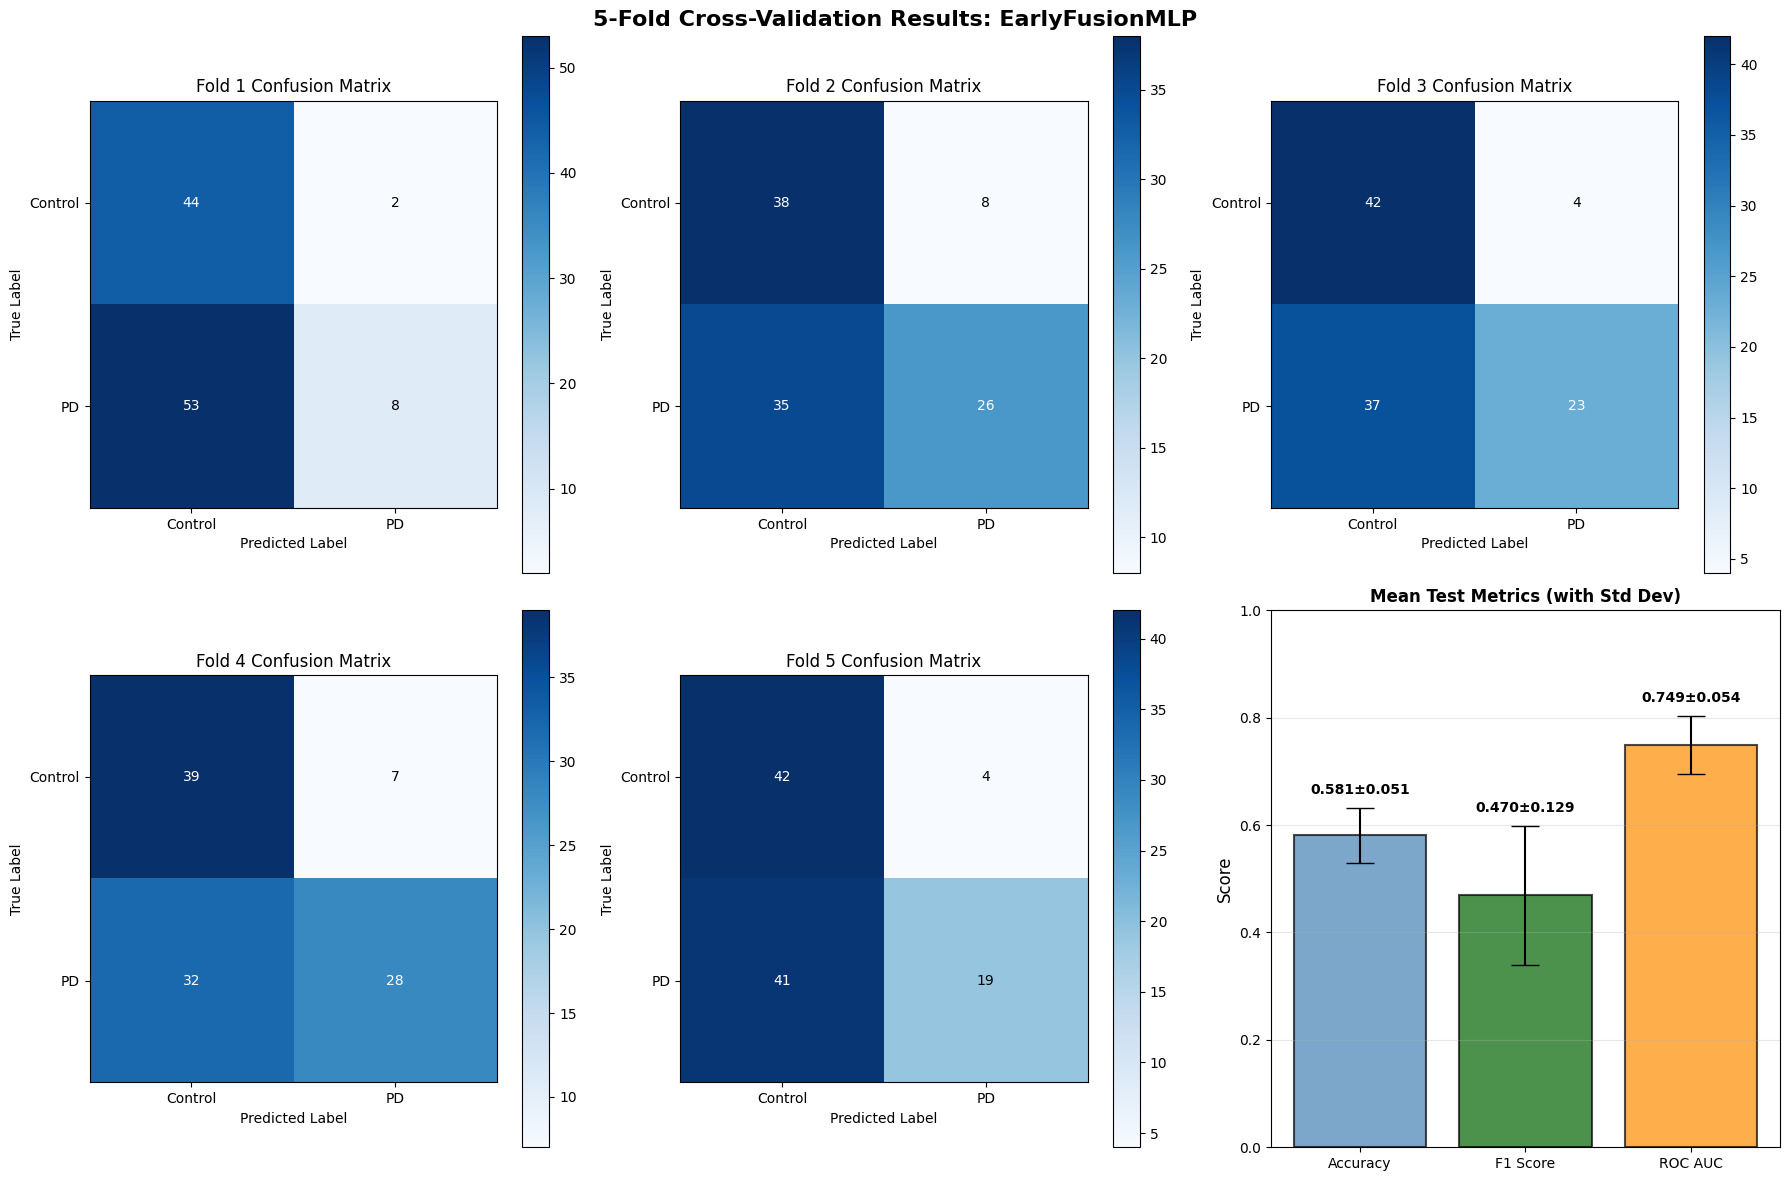


Summary Statistics:
Test Accuracy: 0.5810 ± 0.0510
Test F1 Score: 0.4698 ± 0.1294
Test ROC AUC:  0.7493 ± 0.0541


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: MLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(hyperparam_tuning_res['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
means = [hyperparam_tuning_res['mean_test_acc'], hyperparam_tuning_res['mean_test_f1'], hyperparam_tuning_res['mean_test_roc_auc']]
stds = [hyperparam_tuning_res['std_test_acc'], hyperparam_tuning_res['std_test_f1'], hyperparam_tuning_res['std_test_roc_auc']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {hyperparam_tuning_res['mean_test_acc']:.4f} ± {hyperparam_tuning_res['std_test_acc']:.4f}")
print(f"Test F1 Score: {hyperparam_tuning_res['mean_test_f1']:.4f} ± {hyperparam_tuning_res['std_test_f1']:.4f}")
print(f"Test ROC AUC:  {hyperparam_tuning_res['mean_test_roc_auc']:.4f} ± {hyperparam_tuning_res['std_test_roc_auc']:.4f}")